In [2]:
import sympy as sm
import sympy.physics.mechanics as me
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ModalFlexBody import ModalFlexBody
# from sympy import latex
from IPython.display import display, Math


from utils.abm4 import abm4_integrate
from utils.sym import smaa,split_by_symbol,dcm_sma,dcm_sma_2nd_order,truncate_matrix
from utils.latex import print_simple,latex

me.init_vprinting(use_latex="mathjax")


#### 4.4 Two degrees of freedom model of an onshore or fixed-bottom turbine
![Screenshot from 2026-03-24 17-24-19.png](<attachment:Screenshot from 2026-03-24 17-24-19.png>)
![Screenshot from 2026-03-16 16-14-27.png](<attachment:Screenshot from 2026-03-16 16-14-27.png>)
![Screenshot from 2026-03-16 16-11-38.png](<attachment:Screenshot from 2026-03-16 16-11-38.png>)
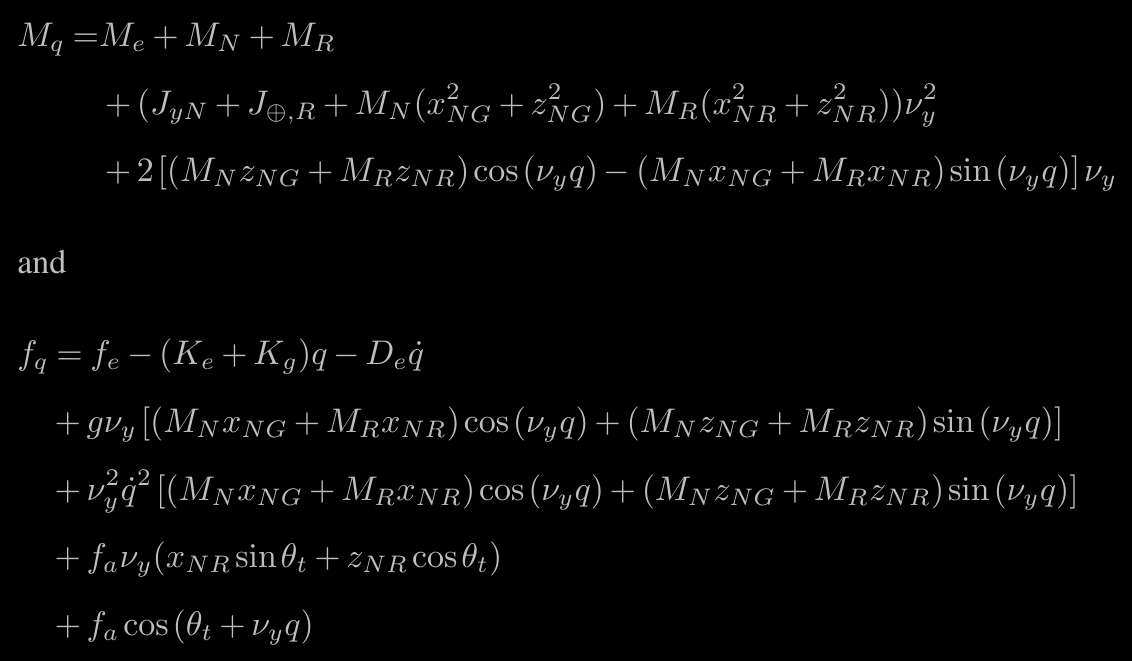
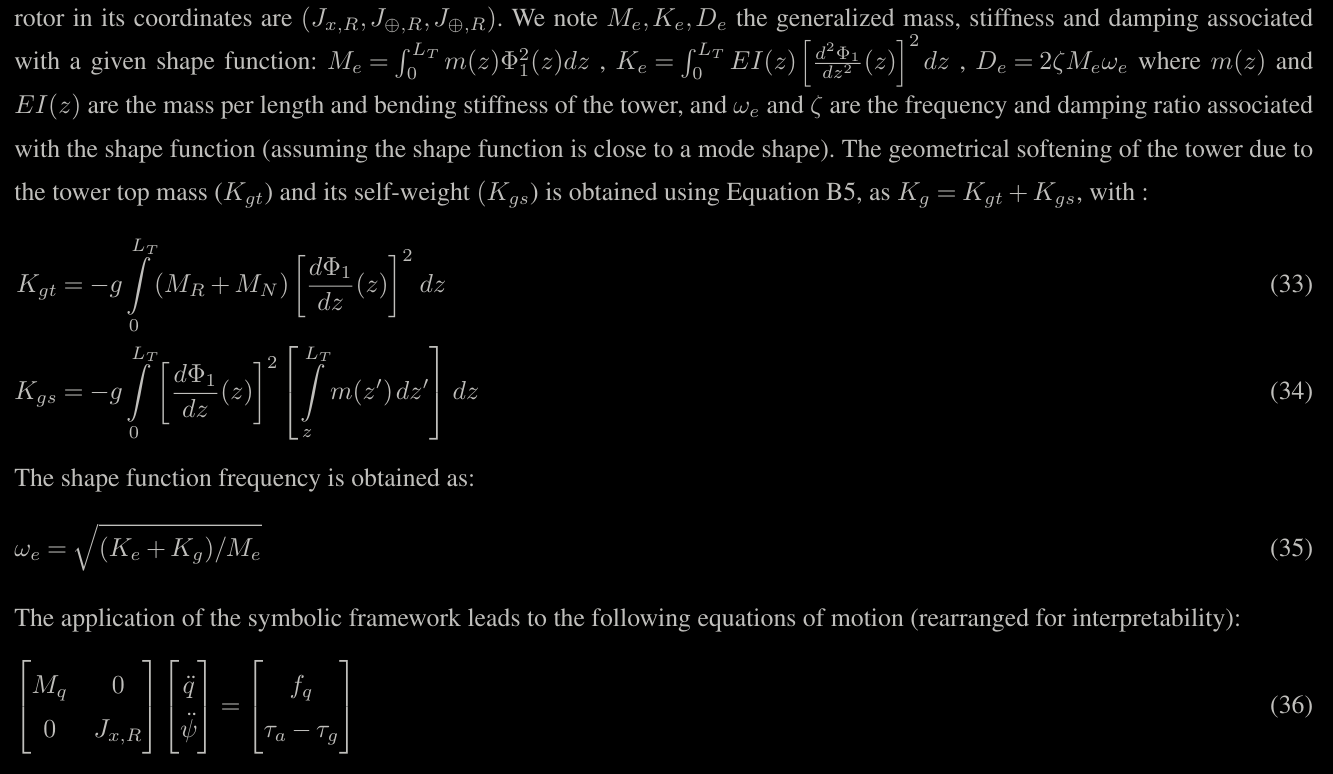
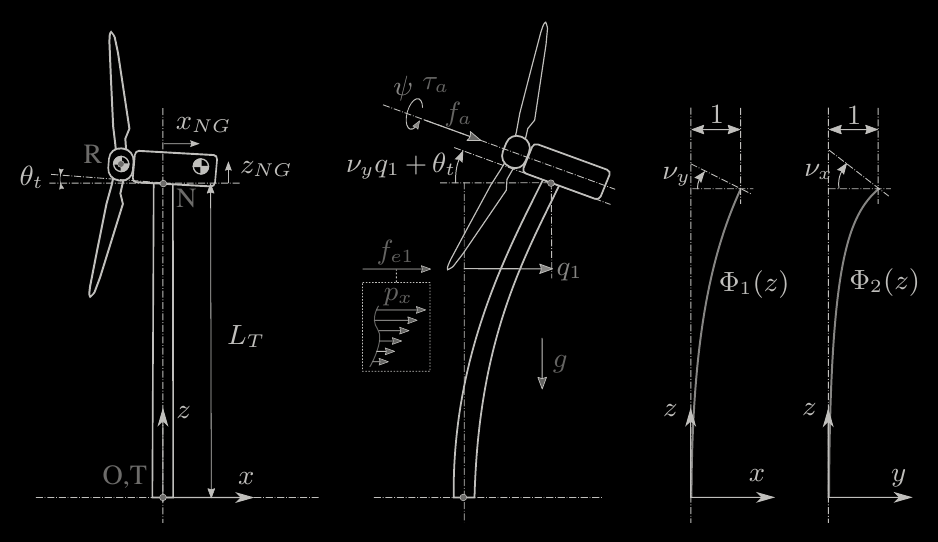

In [4]:
t = me.dynamicsymbols._t
# masses
m_nac, m_rot = sm.symbols("M_n, M_r")

# distances
xn_cm, zn_cm,xr_cm, zr_cm, h_t, h_t_cm = sm.symbols("x_NG, z_NG,x_NR, z_NR,L_t, h_t_cm")

Jxx_n, Jyy_n, Jzz_n = sm.symbols("J_xn,J_yn,J_zn")
J_x, J_p = sm.symbols("J_x,J_p")

# fixed angles
z, g, tilt = sm.symbols("z, g,theta_t")

# Torques and Forces
force_wind, torque_wind, torque_gen = sm.symbols("F_a,Tau_a,Tau_g")

q2, u2 = me.dynamicsymbols("q2,u2")

In [5]:
E = me.ReferenceFrame("E")  # Earth
## Points
og = me.Point("O")
og.set_vel(E, 0)
nu_y = sm.symbols('nu_y')
tower = ModalFlexBody(E,og,'tower',zcm=h_t_cm,dof_x=1,rx=(nu_y,))
q1, = tower.q
u1, = tower.u

N = me.ReferenceFrame("N")  # Nacelle, rotated by tower deformations
N.orient_axis(E, E.y,tower.theta_x)
# N.orient_dcm(E,dcm_sma(tower.theta_x,0))

H = me.ReferenceFrame("H")  # hub
H.orient_axis(N, N.y, tilt ) 
# H.orient_dcm(N, dcm_sma(tilt,0) ) 

R = me.ReferenceFrame("R")
R.orient_axis(H, H.x, q2) 
R.set_ang_vel(H, u2 * H.x)

towertop = og.locatenew("TTP", h_t * E.z + q1 * E.x)
nacelle_cm = towertop.locatenew("nac_cm", zn_cm*N.z + xn_cm*N.x)
rotor_cm = towertop.locatenew("rot_cm", zr_cm*N.z + xr_cm*N.x)

I_rotor = me.inertia(R, J_x, J_p, J_p)
I_nacelle = me.inertia(E, Jxx_n, Jyy_n, Jzz_n)
nacelle = me.RigidBody("nacelle", nacelle_cm, N, m_nac, (I_nacelle, nacelle_cm))
rotor = me.RigidBody("rotor", rotor_cm, R, m_rot, (I_rotor, rotor_cm))

loads = [
    (rotor_cm, -m_rot * g * E.z),
    (rotor_cm, force_wind * R.x),
    (nacelle_cm, -m_nac * g * E.z),
    (R, torque_wind * R.x),
    (R, -torque_gen * R.x),
    (N, torque_gen * H.x), 
]
bodies =  [nacelle, rotor] + tower.get_bodies()
loads = loads + tower.loads

coordinates = [q1, q2]
speeds = [u1, u2]
kin_eqs = [q1.diff(t) - u1, q2.diff(t) - u2]

# # 5. Set up Kane’s method
KM = me.KanesMethod(E, q_ind=coordinates, u_ind=speeds, kd_eqs=kin_eqs)

# # # 4) form the equations
fr, frstar = KM.kanes_equations(bodies=bodies, loads=loads)

/home/lorenzo/miniconda3/envs/openfast/lib/python3.12/site-packages/sympy/physics/vector/point.py:577: UserWarning: 
Velocity of nac_cm automatically calculated based on point O but it is
also possible from points(s): [rot_cm]. Velocities from these points
are not necessarily the same. This may cause errors in your
calculations.
  warn(filldedent(f"""


In [6]:
M = sm.simplify(KM.mass_matrix)
F = sm.simplify(KM.forcing)

In [7]:
sm.simplify(M[0,0].collect(nu_y).collect(sm.sin(tower.theta_x)).collect(sm.cos(tower.theta_x)).collect(m_nac).collect(m_rot))

                      2 ⎛               ⎛    2       2⎞      ⎛    2       2⎞⎞  ↪
Mₙ + Mᵣ + m_xT_1 + ν_y ⋅⎝Jₚ + J_yn + Mₙ⋅⎝x_NG  + z_NG ⎠ + Mᵣ⋅⎝x_NR  + z_NR ⎠⎠  ↪

↪                                                                            
↪ - 2⋅ν_y⋅((Mₙ⋅x_NG + Mᵣ⋅x_NR)⋅sin(ν_y⋅q₁) - (Mₙ⋅z_NG + Mᵣ⋅z_NR)⋅cos(ν_y⋅q₁))

In [11]:
facoef, rest = split_by_symbol(sm.expand(F[0]), force_wind)
u1coef, rest = split_by_symbol(rest, u1)
q1coef, rest = split_by_symbol(rest, q1)
gnucoef, rest = split_by_symbol(rest, g*nu_y)
unu2coef, rest = split_by_symbol(rest, (nu_y*u1)**2)

In [12]:
force_wind*facoef+u1*u1coef +q1*q1coef+ (g*nu_y+(nu_y*u1)**2)*gnucoef

                                                                               ↪
Fₐ⋅(ν_y⋅x_NR⋅sin(θₜ) + ν_y⋅z_NR⋅cos(θₜ) + cos(ν_y⋅q₁ + θₜ)) - c_xT_1⋅u₁ - k_xT ↪

↪         ⎛           2   2⎞                                                   ↪
↪ _1⋅q₁ + ⎝g⋅ν_y + ν_y ⋅u₁ ⎠⋅(Mₙ⋅x_NG⋅cos(ν_y⋅q₁) + Mₙ⋅z_NG⋅sin(ν_y⋅q₁) + Mᵣ⋅x ↪

↪                                       
↪ _NR⋅cos(ν_y⋅q₁) + Mᵣ⋅z_NR⋅sin(ν_y⋅q₁))

In [13]:
facoef, rest = split_by_symbol(sm.expand(F[0]), force_wind)
q1coef, rest = split_by_symbol(rest, q1)
u1coef, rest = split_by_symbol(rest, u1)
gnucoef, rest = split_by_symbol(rest, g*nu_y)
unu2coef, rest = split_by_symbol(rest, (nu_y*u1)**2)

# Create LaTeX table
table = r"""
\Large
\begin{array}{|l|l|}
\hline
\text{Coefficient} & \text{Expression} \\
\hline
f_a & """ + latex(facoef.collect(nu_y)) + r""" \\
\hline
q_1 & """ + latex(q1coef) + r""" \\
\hline
u_1 & """ + latex(u1coef) + r""" \\
\hline
g\nu_y & """ + latex(gnucoef.collect(sm.cos(tower.theta_x)).collect(sm.sin(tower.theta_x))) + r""" \\
\hline
(\nu_y u_1)^2 & """ + latex(unu2coef.collect(sm.cos(tower.theta_x)).collect(sm.sin(tower.theta_x))) + r""" \\
\hline
\end{array}
"""

display(Math(table))

<IPython.core.display.Math object>

In [16]:
## numerical values
K_e = 1.91e6            # K_e - [N/m or Nm/rad?]
K_g = -6.20e4           # K_g = -5.2e4 - 1.0e4 = -6.20e4 [units?]
M_e = 5.4e4
zeta = 0.01

m_fa1 = tower.m[0]
k_fa1 = tower.k[0]
c_fa1 = tower.c[0]

subs = {
    # Masses
    m_nac: 2.4e5,           # M_n [kg]
    m_rot: 1.1e5,           # M_r [kg]
    
    # Distances and positions [m]
    xn_cm: 1.9,             # x_NG
    zn_cm: 1.75,            # z_NG
    xr_cm: -5.0,            # x_NR
    zr_cm: 2.4,             # z_NR
    h_t: 87.6,              # L_t
    # h_t_cm: ???,          # Still need value for tower CM height
    
    # Moments of inertia [kg m²]
    J_x: 3.86e7,            # J_x (rotor shaft inertia)
    J_p: 1.92e7,            # J_p (rotor perpendicular axis) - from J⊕,R
    Jxx_n: 1.01e6,          # J_xn (nacelle x-axis inertia)
    Jyy_n: 1.01e6,          # J_yn (nacelle y-axis inertia)
    Jzz_n: 1.01e6,          # J_zn (nacelle z-axis inertia)
    
    # Constants
    g: 9.807,               # gravitational acceleration [m/s²]
    tilt: np.deg2rad(5),    # theta_t converted from degrees to radians
    
    nu_y: 0.0185,           # νy - tower bending coefficient? [unitless or rad?]
    m_fa1: M_e,             # M_e - [kg or Nm?]
    k_fa1: K_e+K_g,
    c_fa1: zeta*np.sqrt(M_e*(K_e+K_g)),
    force_wind:0,
    torque_gen:0,
    torque_wind:0,
}

In [17]:
def M_q(q):
    term1 = m_fa1 + m_nac + m_rot

    term2 = (Jyy_n + J_p
             + m_nac * (xn_cm**2 + zn_cm**2)
             + m_rot * (xr_cm**2 + zr_cm**2)
             ) * nu_y**2

    term3 = 2 * (
        (m_nac * zn_cm + m_rot * zr_cm) * sm.cos(nu_y * q)
      - (m_nac * xn_cm + m_rot * xr_cm) * sm.sin(nu_y * q)
    ) * nu_y

    return term1 + term2 + term3


def f_q(q, q_dot):
    cross_x = m_nac * xn_cm + m_rot * xr_cm
    cross_z = m_nac * zn_cm + m_rot * zr_cm
    term1 = - k_fa1 * q - c_fa1 * q_dot
    term2 = g * nu_y * (cross_x * sm.cos(nu_y * q) + cross_z * sm.sin(nu_y * q))
    term3 = nu_y**2 * q_dot**2 * (cross_x * sm.cos(nu_y * q) + cross_z * sm.sin(nu_y * q))
    term4 = force_wind * nu_y * (xr_cm * sm.sin(tilt) + zr_cm * sm.cos(tilt))
    term5 = force_wind * sm.cos(tilt + nu_y * q)

    return term1 + term2 + term3 + term4 + term5

### Three DOF
![Screenshot from 2026-03-16 16-10-07.png](<attachment:Screenshot from 2026-03-16 16-10-07.png>)
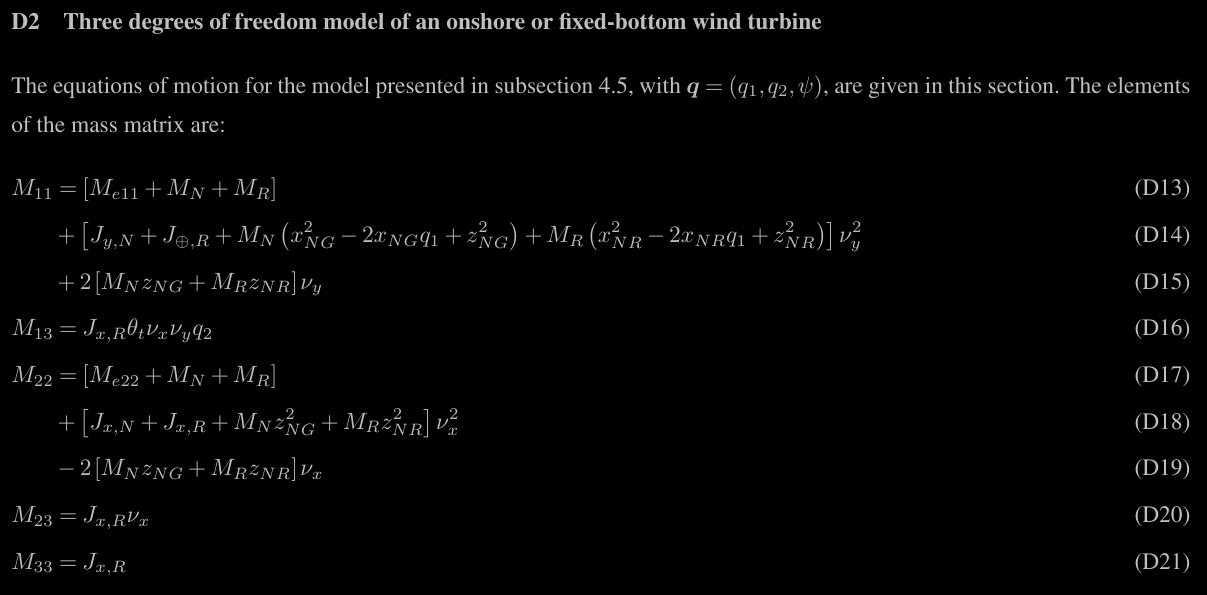

In [18]:
E = me.ReferenceFrame("E")  # Earth
## Points
og = me.Point("O")
og.set_vel(E, 0)
nu_y,nu_x = sm.symbols('nu_y,nu_x')
tower = ModalFlexBody(E,og,'tower',zcm=h_t_cm,dof_x=1,dof_y=1,rx=(nu_y,),ry=(nu_x,))
q1,q2 = tower.q
u1,u2 = tower.u
q3, u3 = me.dynamicsymbols("q3,u3")

N = me.ReferenceFrame("N")  # Nacelle, rotated by tower deformations
N.orient_body_fixed(E, (tower.theta_x,tower.theta_y, 0), "YXZ")
# N.orient_dcm(E,dcm_sma(tower.theta_x,tower.theta_y))
# N.orient_dcm(E,dcm_sma_2nd_order(tower.theta_x,tower.theta_y))

H = me.ReferenceFrame("H")  # hub
# H.orient_axis(N, N.y, tilt )
H.orient_dcm(N, dcm_sma(tilt,0) )

R = me.ReferenceFrame("R")
R.orient_axis(H, H.x, q3)
R.set_ang_vel(H, u3 * H.x)

towertop = og.locatenew("TTP", h_t * E.z + q1 * E.x + q2*E.y)
nacelle_cm = towertop.locatenew("nac_cm", zn_cm*N.z + xn_cm*N.x)
rotor_cm = towertop.locatenew("rot_cm", zr_cm*N.z + xr_cm*N.x)

I_rotor = me.inertia(H, J_x, J_p, J_p)
# I_nacelle = me.inertia(N, Jxx_n, Jyy_n, Jzz_n)
I_nacelle = me.inertia(E, Jxx_n, Jyy_n, Jzz_n)

# nacelle = me.Particle("nacelle", nacelle_cm, m_nac)
nacelle = me.RigidBody("nacelle", nacelle_cm, N, m_nac, (I_nacelle, nacelle_cm))
rotor = me.RigidBody("rotor", rotor_cm, R, m_rot, (I_rotor, rotor_cm))
# 2) your existing loads (gravity):

loads = [
    # (tower_cm,   -m_t * g * E.z),
    # (rotor_cm, quad_damp_force * E.x), # quad force
    (rotor_cm, -m_rot * g * E.z),
    (rotor_cm, force_wind * R.x),
    (nacelle_cm, -m_nac * g * E.z),
    (R, torque_wind * R.x),
    (R, -torque_gen * R.x),
    (N, torque_gen * H.x), 
]

## add tower contribution to loads and bodies
bodies =  [nacelle, rotor] + tower.get_bodies()
loads = loads + tower.loads

coordinates = [q1, q2,q3]
speeds = [u1, u2,u3]
kin_eqs = [q1.diff(t) - u1, q2.diff(t) - u2,q3.diff(t) - u3]

nacelle_cm.v1pt_theory(og,E,E)
# # 5. Set up Kane’s method
KM = me.KanesMethod(E, q_ind=coordinates, u_ind=speeds, kd_eqs=kin_eqs)

# # # 4) form the equations
fr, frstar = KM.kanes_equations(bodies=bodies, loads=loads)

/home/lorenzo/miniconda3/envs/openfast/lib/python3.12/site-packages/sympy/physics/vector/point.py:577: UserWarning: 
Velocity of rot_cm automatically calculated based on point O but it is
also possible from points(s): [nac_cm]. Velocities from these points
are not necessarily the same. This may cause errors in your
calculations.
  warn(filldedent(f"""


In [19]:
M = sm.trigsimp(KM.mass_matrix)
F = sm.trigsimp(KM.forcing)
M = truncate_matrix(truncate_matrix(M,[nu_x,nu_y],2),[tilt],1)
F = truncate_matrix(truncate_matrix(F,[nu_x,nu_y],2),[tilt],1)

In [20]:
M[0,1].collect(m_nac).collect(m_rot)

-Jₚ⋅νₓ⋅ν_y⋅θₜ⋅sin(νₓ⋅q₂) + Jₓ⋅νₓ⋅ν_y⋅θₜ⋅sin(νₓ⋅q₂) + Mₙ⋅(νₓ⋅ν_y⋅x_NG⋅z_NG⋅sin( ↪

↪ νₓ⋅q₂) - νₓ⋅z_NG⋅sin(νₓ⋅q₂)⋅sin(ν_y⋅q₁)) + Mᵣ⋅(νₓ⋅ν_y⋅x_NR⋅z_NR⋅sin(νₓ⋅q₂) - ↪

↪  νₓ⋅z_NR⋅sin(νₓ⋅q₂)⋅sin(ν_y⋅q₁))

In [21]:
sm.simplify(M[1,1].collect(nu_x**2).collect(nu_x).collect(m_nac).collect(m_rot))

                     2 ⎛            2                   2                  2   ↪
Mₙ + Mᵣ + m_yT_1 + νₓ ⋅⎝Jₓ + Jₓₙ⋅cos (ν_y⋅q₁) + J_zn⋅sin (ν_y⋅q₁) + Mₙ⋅z_NG  + ↪

↪         2⎞                                      
↪  Mᵣ⋅z_NR ⎠ - 2⋅νₓ⋅(Mₙ⋅z_NG + Mᵣ⋅z_NR)⋅cos(νₓ⋅q₂)

In [22]:
## numerical values
K_e = 1.91e6            # K_e - [N/m or Nm/rad?]
K_g = -6.20e4           # K_g = -5.2e4 - 1.0e4 = -6.20e4 [units?]
M_e = 5.4e4
zeta = 0.01

m_fa1 = tower.m[0]
k_fa1 = tower.k[0]
c_fa1 = tower.c[0]
m_ss1 = tower.m[1]
k_ss1 = tower.k[1]
c_ss1 = tower.c[1]

subs = {
    # Masses
    m_nac: 2.4e5,           # M_n [kg]
    m_rot: 1.1e5,           # M_r [kg]
    
    # Distances and positions [m]
    xn_cm: 1.9,             # x_NG
    zn_cm: 1.75,            # z_NG
    xr_cm: -5.0,            # x_NR
    zr_cm: 2.4,             # z_NR
    h_t: 87.6,              # L_t
    # Moments of inertia [kg m²]
    J_x: 3.86e7,            # J_x (rotor shaft inertia)
    J_p: 1.92e7,            # J_p (rotor perpendicular axis) - from J⊕,R
    Jxx_n: 1.01e6,          # J_xn (nacelle x-axis inertia)
    Jyy_n: 1.01e6,          # J_yn (nacelle y-axis inertia)
    Jzz_n: 1.01e6,          # J_zn (nacelle z-axis inertia)
    # Constants
    g: 9.807,               # gravitational acceleration [m/s²]
    tilt: np.deg2rad(5),    # theta_t converted from degrees to radians
    nu_y: 0.0185,           # νy - tower bending coefficient? [unitless or rad?]
    nu_x: 0.0185,           # νy - tower bending coefficient? [unitless or rad?]
    m_fa1: M_e,             # M_e - [kg or Nm?]
    k_fa1: K_e+K_g,
    c_fa1: zeta*np.sqrt(M_e*(K_e+K_g)),
    m_ss1: M_e,             # M_e - [kg or Nm?]
    k_ss1: K_e+K_g,
    c_ss1: zeta*np.sqrt(M_e*(K_e+K_g))
}

def mass_matrix(q1, q2):
    M11 = (
        (m_fa1 + m_nac + m_rot)
        + (Jyy_n + J_p
           + m_nac * (xn_cm**2 - 2*xn_cm*q1 + zn_cm**2)
           + m_rot * (xr_cm**2 - 2*xr_cm*q1 + zr_cm**2)
           ) * nu_y**2
        + 2 * (m_nac*zn_cm + m_rot*zr_cm) * nu_y
    )

    M13 = J_x * tilt * nu_x * nu_y * q2

    M22 = (
        (m_ss1 + m_nac + m_rot)
        + (Jxx_n + J_x
           + m_nac * zn_cm**2
           + m_rot * zr_cm**2
           ) * nu_x**2
        - 2 * (m_nac*zn_cm + m_rot*zr_cm) * nu_x
    )

    M23 = J_x * nu_x
    M33 = J_x

    return sm.Matrix([
        [M11,   0,   M13],
        [0,   M22,   M23],
        [M13, M23,   M33]
    ])

def forcing_vector(q1, q2, q1_dot, q2_dot, q3_dot):
    cross_x = m_nac * xn_cm + m_rot * xr_cm
    cross_z = m_nac * zn_cm + m_rot * zr_cm

    f1 = (
        - k_fa1 * q1 - c_fa1 * q1_dot
        - J_x * tilt * nu_x * nu_y * q3_dot * q2_dot
        + cross_x * nu_y**2 * q1_dot**2
        + g * (m_nac * (nu_y**2 * zn_cm * q1 + nu_y * xn_cm)
             + m_rot * (nu_y**2 * zr_cm * q1 + nu_y * xr_cm))
        + force_wind * (tilt * nu_x * xr_cm - tilt * nu_y * q1 + nu_y * zr_cm + 1)
    )

    f2 = (
        - k_ss1 * q2 - c_ss1 * q2_dot
        + J_x * tilt * nu_x * nu_y * q3_dot * q1_dot
        + g * cross_z * nu_x**2 * q2
        + force_wind * tilt * nu_x * q2
    )

    f3 = (
        - J_x * tilt * nu_x * nu_y * q1_dot * q2_dot
        + torque_wind
    )

    return sm.Matrix([f1, f2, f3])

m_branlard = mass_matrix(q1,q2)
f_branlard = forcing_vector(q1,q2,u1,u2,u3)

In [23]:
qsubs = {q1:4.0,q2:0.1,q3:2.0,u1:-0.1,u2:0.05,u3:0.01}
fsubs = {force_wind:3000,torque_gen:0,torque_wind:1000}
statevars =(q1,q2,q3,u1,u2,u3)

In [24]:
mfunc_rom = sm.lambdify(statevars,M.subs(subs))
mfunc_branlard = sm.lambdify(statevars,m_branlard.subs(subs))

ffunc_rom = sm.lambdify([*statevars,*fsubs.keys()],F.subs(subs))
ffunc_branlard = sm.lambdify([*statevars,*fsubs.keys()],f_branlard.subs(subs))

In [25]:
# q1:0.1, q2:0.1, q3:0

In [26]:
t_span = (0, 120)
dt     = 0.005

ext_forcing_step = lambda t: (1.5e6, 0, 0) if t < 10 else (0, 0, 0)
ext_forcing_impulse = lambda t: (1.5e6 / dt, 0, 0) if t < dt else (0, 0, 0)
f_start, f_end = 0.005, 0.4   # Hz — bracket expected FA frequency
def ext_forcing_chirp(t):
    f = f_start + (f_end - f_start) * t / t_span[1]
    F = 5e5 * np.sin(2 * np.pi * f * t)
    return (F, 0, 0)
omega_FA = 2 * np.pi * 0.32   # rad/s — replace with measured value from test 2
def ext_forcing_resonance(t):
    F = 5e5 * np.sin(omega_FA * t)
    return (F, 0, 0)
omega_SS = 2 * np.pi * 0.31   # side-side freq, typically slightly different
def ext_forcing_coupled(t):
    F_fa = 8e5 * np.sin(omega_FA * t)
    F_ss = 6e5 * np.sin(omega_SS * t)
    return (F_fa, F_ss, 0)
def ext_forcing_torque_step(t):
    Tau_g = -4.5e6 if t < 5 else 0.0   # rated torque, then trip
    return (0, 0, Tau_g)
omega_1P = 2 * np.pi * 0.2   # 12 RPM
F_thrust_mean = 1.5e6
def ext_forcing_operational(t):
    ramp = min(t / 10.0, 1.0)           # 10 s soft start
    F_a  = ramp * (F_thrust_mean + 2e5 * np.sin(omega_1P * t))
    Tau_a = ramp * 4.5e6                # constant aero torque
    Tau_g = -ramp * 4.5e6              # generator resists
    return (F_a, 0, Tau_a + Tau_g)

In [27]:
y0     = [0, 0, 0, 0, 0, 0]   # [q1, q2, q3, u1, u2, u3]

ext_forcing = lambda t: (1.5e6,0,0) if t<10 else (0,0,0) #'F_a', 'Tau_g', and 'Tau_a'

t_rom,      Y_rom      = abm4_integrate(mfunc_rom,      ffunc_rom,      t_span, y0, dt,ext_func=ext_forcing_operational)
t_branlard, Y_branlard = abm4_integrate(mfunc_branlard, ffunc_branlard, t_span, y0, dt,ext_func=ext_forcing_operational)

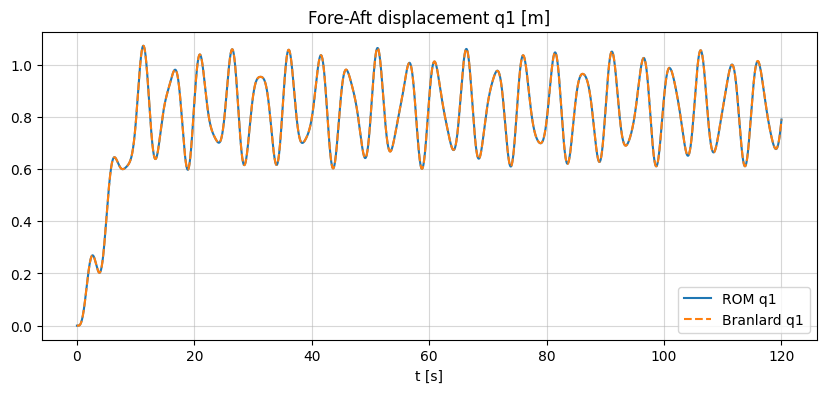

In [28]:
# Compare q1 (fore-aft)
plt.figure(figsize=(10,4))
plt.plot(t_rom,      Y_rom[:,0],      label='ROM q1')
plt.plot(t_branlard, Y_branlard[:,0], label='Branlard q1', linestyle='--')
plt.title('Fore-Aft displacement q1 [m]')
plt.legend(); plt.xlabel('t [s]'); plt.grid(alpha=0.5); plt.show()

In [29]:
facoef, rest = split_by_symbol(sm.expand(F[0]), force_wind)
q1coef, rest = split_by_symbol(rest, q1)
u1coef, rest = split_by_symbol(rest, u1)
gnucoef, rest = split_by_symbol(rest, g*nu_y)
unu2coef, rest = split_by_symbol(rest, (nu_y*u1)**2)

# Create LaTeX table
table = r"""
\Large
\begin{array}{|l|l|}
\hline
\text{Coefficient} & \text{Expression} \\
\hline
f_a & """ + latex(facoef.collect(nu_y)) + r""" \\
\hline
q_1 & """ + latex(q1coef) + r""" \\
\hline
u_1 & """ + latex(u1coef) + r""" \\
\hline
g\nu_y & """ + latex(gnucoef.collect(sm.cos(tower.theta_x)).collect(sm.sin(tower.theta_x))) + r""" \\
\hline
(\nu_y u_1)^2 & """ + latex(unu2coef.collect(sm.cos(tower.theta_x)).collect(sm.sin(tower.theta_x))) + r""" \\
\hline
1 & """ + latex(rest) + r""" \\
\hline
\end{array}
"""

display(Math(table))

<IPython.core.display.Math object>

In [30]:
facoef, rest = split_by_symbol(sm.expand(F[1]), force_wind)
q2coef, rest = split_by_symbol(rest, q2)
u2coef, rest = split_by_symbol(rest, u2)
gnuxcoef, rest = split_by_symbol(rest, g*nu_x)
unux2coef, rest = split_by_symbol(rest, (nu_x*u2)**2)

# Create LaTeX table
table = r"""
\Large
\begin{array}{|l|l|}
\hline
\text{Coefficient} & \text{Expression} \\
\hline
f_a & """ + latex(facoef.collect(nu_x)) + r""" \\
\hline
q_2 & """ + latex(q2coef) + r""" \\
\hline
u_2 & """ + latex(u2coef) + r""" \\
\hline
g\nu_x & """ + latex(gnuxcoef.collect(sm.cos(tower.theta_y)).collect(sm.sin(tower.theta_y))) + r""" \\
\hline
(\nu_x u_2)^2 & """ + latex(unux2coef.collect(sm.cos(tower.theta_y)).collect(sm.sin(tower.theta_y))) + r""" \\
\hline
1 & """ + latex(rest) + r""" \\
\hline
\end{array}
"""

display(Math(table))

<IPython.core.display.Math object>

In [31]:
rest

Jₓ⋅νₓ⋅ν_y⋅θₜ⋅u₁⋅u₃⋅cos(νₓ⋅q₂) + Τₐ⋅νₓ

In [32]:
M[0,0]

      2           2         2     2         2     2    2                       ↪
Jₚ⋅ν_y  + J_yn⋅ν_y  + Mₙ⋅ν_y ⋅x_NG  + Mₙ⋅ν_y ⋅z_NG ⋅cos (νₓ⋅q₂) - 2⋅Mₙ⋅ν_y⋅x_N ↪

↪                                                                   2     2    ↪
↪ G⋅sin(ν_y⋅q₁) + 2⋅Mₙ⋅ν_y⋅z_NG⋅cos(νₓ⋅q₂)⋅cos(ν_y⋅q₁) + Mₙ + Mᵣ⋅ν_y ⋅x_NR  +  ↪

↪       2     2    2                                                           ↪
↪ Mᵣ⋅ν_y ⋅z_NR ⋅cos (νₓ⋅q₂) - 2⋅Mᵣ⋅ν_y⋅x_NR⋅sin(ν_y⋅q₁) + 2⋅Mᵣ⋅ν_y⋅z_NR⋅cos(νₓ ↪

↪                               
↪ ⋅q₂)⋅cos(ν_y⋅q₁) + Mᵣ + m_xT_1

In [33]:
nu_y2coef, rest = split_by_symbol(sm.expand(M[0,0]), nu_y**2)
nu_ycoef, rest = split_by_symbol(rest, nu_y)
# Create LaTeX table
table = r"""
\Large
\begin{array}{|l|l|}
\hline
\text{Coefficient} & \text{Expression} \\
\hline
\nu_y^2 & """ + latex(nu_y2coef) + r""" \\
\hline
\nu_y & """ + latex(nu_ycoef) + r""" \\
\hline
1 & """ + latex(rest) + r""" \\
\hline
\end{array}
"""

display(Math(table))

<IPython.core.display.Math object>

In [34]:
nu_x2coef, rest = split_by_symbol(sm.expand(M[1,1]), nu_x**2)
nu_xcoef, rest = split_by_symbol(rest, nu_x)
# Create LaTeX table
table = r"""
\Large
\begin{array}{|l|l|}
\hline
\text{Coefficient} & \text{Expression} \\
\hline
\nu_x^2 & """ + latex(nu_x2coef) + r""" \\
\hline
\nu_x & """ + latex(nu_xcoef) + r""" \\
\hline
1 & """ + latex(rest) + r""" \\
\hline
\end{array}
"""

display(Math(table))

<IPython.core.display.Math object>

In [35]:
M[0,1]

-Jₚ⋅νₓ⋅ν_y⋅θₜ⋅sin(νₓ⋅q₂) + Jₓ⋅νₓ⋅ν_y⋅θₜ⋅sin(νₓ⋅q₂) + Mₙ⋅νₓ⋅ν_y⋅x_NG⋅z_NG⋅sin(ν ↪

↪ ₓ⋅q₂) - Mₙ⋅νₓ⋅z_NG⋅sin(νₓ⋅q₂)⋅sin(ν_y⋅q₁) + Mᵣ⋅νₓ⋅ν_y⋅x_NR⋅z_NR⋅sin(νₓ⋅q₂) - ↪

↪  Mᵣ⋅νₓ⋅z_NR⋅sin(νₓ⋅q₂)⋅sin(ν_y⋅q₁)

In [36]:
M[0,2]

Jₓ⋅ν_y⋅θₜ⋅sin(νₓ⋅q₂)

In [37]:
M[1,2]

Jₓ⋅νₓ